# 2. Neural Networks with Numpy - Solution

In this notebook we will build our first neural network using only `numpy` as library.

We will work on the same dataset as last week and try to predict which digit is shown on the given pixel values.

In [1]:
from sklearn.datasets import fetch_openml
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, data_home="./data", cache=True, parser='auto')

We know already from last time how the data looks:

In [2]:
X.head(3)

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


The label is a number between 0-9 representing the digit shown on the pixels.

In [3]:
y.head(3)

0    5
1    0
2    4
Name: class, dtype: category
Categories (10, object): ['0', '1', '2', '3', ..., '6', '7', '8', '9']

As we can see from above, the label is given as a digit. However, to calculate the loss function of the neural network, we need the label as a one-hot-encoded version, in which the label is encoded as `1` and the rest as `0`.

For instance:
- `3` -> `[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]`
- `9` -> `[0, 0, 0, 0, 0, 0, 0, 0, 0, 1]`

This is done in the following:

In [4]:
import pandas as pd
y_categorical = pd.get_dummies(y).astype('float32').values
y_categorical[0:5]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]], dtype=float32)

Before we start, we scale the data and divide it into train and test data:

In [5]:
from sklearn.model_selection import train_test_split

X_scaled = (X/255).astype('float32').values
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_categorical, test_size=0.15, random_state=42)

## Task 1: Implement the Forward pass

We start with the following structure of a neural network with two hidden layers:
- Input layer of size 784 (the pixel values, no activation)
- First hidden layer of size 128 with sigmoid activation
- Second hidden layer of size 64 with sigmoid activation
- Output layer of size 10 with softmax activation

For simplicity, the network has no bias terms and the weights are initialized from a standard normal distribution. In practice, one would add biases and scale the initial weights (e.g. by `1/sqrt(n_inputs)`) so that the sigmoids do not saturate.

A skeleton code for this network is given in the following class. Your first task is to complete the method `forward_pass` to calculate the forward pass on one data point. After this class you can find a test to check whether your implementation is correct.

In [6]:
import time
import numpy as np

class DeepNeuralNetwork():
    def __init__(self):
        
        # initialize weights randomly
        np.random.seed(0)
        self.w1 = np.random.randn(128, 784)
        self.w2 = np.random.randn(64, 128)
        self.w3 = np.random.randn(10, 64)

    def forward_pass(self, x_train):
        z1 = np.dot(self.w1, x_train)
        a1 = 1/(1 + np.exp(-z1)) # sigmoid activation
        z2 = np.dot(self.w2, a1)
        a2 = 1/(1 + np.exp(-z2)) # sigmoid activation
        z3 = np.dot(self.w3, a2)
        exps = np.exp(z3) 
        a3 = exps / exps.sum() # softmax activation
        
        # we need to remember all values for the gradient calculation
        self.fwdpass = [x_train, z1, a1, z2, a2, z3, a3]
        
        return a3
    
    
    def get_gradients(self, y, y_hat):
        # restore values from foward pass
        a0, z1, a1, z2, a2, z3, a3 = self.fwdpass
        
        # Calculate W3 update
        # for softmax + cross-entropy loss, the error at the output simplifies to y_hat - y
        error = y_hat - y
        gradient_w3 = np.outer(error, a2)

        # Calculate W2 update
        sigmoid_derivative = (np.exp(-z2))/((np.exp(-z2)+1)**2)
        error = np.dot(self.w3.T, error) * sigmoid_derivative
        gradient_w2 = np.outer(error, a1)

        # Calculate W1 update
        sigmoid_derivative = (np.exp(-z1))/((np.exp(-z1)+1)**2)
        error = np.dot(self.w2.T, error) * sigmoid_derivative
        gradient_w1 = np.outer(error, a0)

        return [gradient_w1, gradient_w2, gradient_w3]

In [7]:
# Test for task 1:
dnn = DeepNeuralNetwork()

# the network outputs a probability for every neuron in the last layer
y_hat = dnn.forward_pass(X_train[0])
print("The output of the last layer looks like this:\n", y_hat)

# to check if the network works correctly, check if the following condition is True
abs(y_hat[8] - 0.946) < 0.001

The output of the last layer looks like this:
 [5.13892189e-02 4.31072252e-06 2.25095624e-08 4.20524030e-08
 1.16018028e-09 3.04792788e-07 7.17666893e-05 1.95730962e-03
 9.46575277e-01 1.74626318e-06]


True

### Task 2: Evaluate the untrained network

Before we train the network, let's see how well it performs with its random initial weights.

__Task__:
- Implement the function `evaluate(dnn, X, y)`: iterate over the given data and use the network to predict on every data point, identify the index of the neuron which returned the highest probability, compare this value to the true label and return the accuracy.
- Use it to compute the accuracy of the untrained network on the test data. Which accuracy would you expect from random guessing?
- Calculate the log loss (cross-entropy) $-\sum_{c=1}^{M} y_c \log(\hat{y}_c)$ for the first training data point `X_train[0]` with label `y_train[0]`.

In [8]:
def evaluate(dnn, X, y):
    predictions = []
    for x, y_true in zip(X, y):
        output = dnn.forward_pass(x)
        pred = np.argmax(output) # returns the index of the neuron with the highest value
        predictions.append(pred == np.argmax(y_true))
    return np.mean(predictions)

dnn = DeepNeuralNetwork()
print("Accuracy of the untrained network:", evaluate(dnn, X_test, y_test))

Accuracy of the untrained network: 0.10238095238095238


In [9]:
y_hat = dnn.forward_pass(X_train[0])
loss = -np.sum(y_train[0] * np.log(y_hat))
print(loss)

15.00363367410518


### Task 3: Implement the training procedure

We can now start training the network by implementing the training procedure. We train the network for 3 epochs as shown in the code below. One epoch takes about 20 seconds on a recent laptop (it may take longer on yours). At home, try training for 10 epochs and compare the results.
In each epoch we go over every data point `x` in `X_train` and:
1. Calculate a forward pass on `x` as `y_hat`
2. Calculate the gradients for the weight in w1, w2 and w3 using the `get_gradients` function of the network
3. Update the weights w1, w2 and w3 of the network by moving into the negative direction of the gradient multiplied with the `learning_rate`
4. Bonus: Calculate the cross-entropy-loss after each epoch and plot it in relation to the epochs.



In [10]:
dnn = DeepNeuralNetwork()

no_epochs = 3
learning_rate = 0.01

start_time = time.time()
losses = []
for iteration in range(no_epochs):
    loss = 0
    for x,y in zip(X_train, y_train):
        y_hat = dnn.forward_pass(x)
        gradients = dnn.get_gradients(y, y_hat)
        
        loss += -np.log(np.dot(y, y_hat))
        
        # one step stochastic gradient descent
        dnn.w1 -= learning_rate * gradients[0]
        dnn.w2 -= learning_rate * gradients[1]
        dnn.w3 -= learning_rate * gradients[2]

    loss /= len(X_train) # average loss per sample
    print(f'Epoch: {iteration+1}, Time: {time.time() - start_time:.1f}s, Loss: {loss:.4f}')
    losses.append(loss)

Epoch: 1, Time: 18.2s, Loss: 0.6409
Epoch: 2, Time: 39.3s, Loss: 0.3351
Epoch: 3, Time: 59.0s, Loss: 0.2632


Text(0, 0.5, 'average cross-entropy loss')

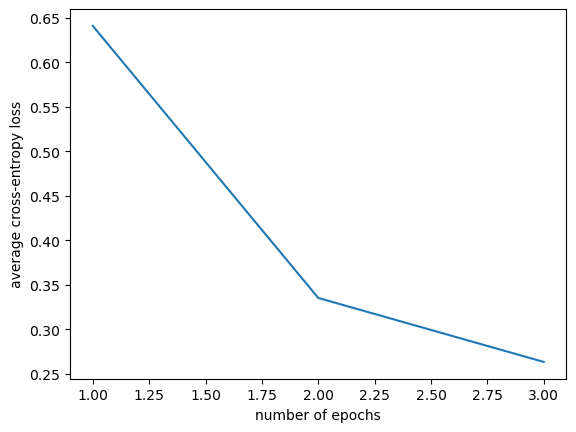

In [11]:
import matplotlib.pyplot as plt
fig = plt.figure()
plt.plot(range(1, no_epochs + 1), losses)
plt.xlabel('number of epochs')
plt.ylabel('average cross-entropy loss')

### Task 4: Evaluate the trained network

Use your `evaluate` function from Task 2 to compute the accuracy of the trained network on the test data. Compare it to the accuracy of the untrained network.

In [12]:
print(evaluate(dnn, X_test, y_test))

0.9128571428571428


### Task 5 (homework)

- Train the network from Task 3 for 10 epochs and check the performance on the test data.
- Remove the first hidden layer. Train the network and check the performance on the test data.

With 10 epochs, the network from Task 3 reaches about 93-94% accuracy on the test data. The network without the first hidden layer is trained below.

In [13]:
class DeepNeuralNetworkSmall():
    def __init__(self):
        
        # initialize weights randomly
        np.random.seed(0)
        self.w1 = np.random.randn(64, 784)
        self.w2 = np.random.randn(10, 64)

    def forward_pass(self, x_train):
        z1 = np.dot(self.w1, x_train)
        a1 = 1/(1 + np.exp(-z1)) # sigmoid activation
        z2 = np.dot(self.w2, a1)
        exps = np.exp(z2)
        a2 = exps / exps.sum() # softmax activation
        
        # we need to remember all values for gradient calculations
        self.fwdpass = [x_train, z1, a1, z2, a2]
        
        return a2
    
    
    def get_gradients(self, y, y_hat):
        # restore values from foward pass
        a0, z1, a1, z2, a2 = self.fwdpass
        
        # Calculate W2 update
        # for softmax + cross-entropy loss, the error at the output simplifies to y_hat - y
        error = y_hat - y
        gradient_w2 = np.outer(error, a1)

        # Calculate W1 update
        sigmoid_derivative = (np.exp(-z1))/((np.exp(-z1)+1)**2)
        error = np.dot(self.w2.T, error) * sigmoid_derivative
        gradient_w1 = np.outer(error, a0)

        return [gradient_w1, gradient_w2]

In [14]:
dnn = DeepNeuralNetworkSmall()

no_epochs = 10
learning_rate = 0.01

start_time = time.time()
losses = []
for iteration in range(no_epochs):
    loss = 0
    for x,y in zip(X_train, y_train):
        y_hat = dnn.forward_pass(x)
        gradients = dnn.get_gradients(y, y_hat)
        
        loss += -np.log(np.dot(y, y_hat))
        
        # one step stochastic gradient descent
        dnn.w1 -= learning_rate * gradients[0]
        dnn.w2 -= learning_rate * gradients[1]

    loss /= len(X_train) # average loss per sample
    print(f'Epoch: {iteration+1}, Time: {time.time() - start_time:.1f}s, Loss: {loss:.4f}')
    losses.append(loss)

Epoch: 1, Time: 10.1s, Loss: 0.6660
Epoch: 2, Time: 20.6s, Loss: 0.3505
Epoch: 3, Time: 29.8s, Loss: 0.2889
Epoch: 4, Time: 38.9s, Loss: 0.2520
Epoch: 5, Time: 48.5s, Loss: 0.2258
Epoch: 6, Time: 57.7s, Loss: 0.2058
Epoch: 7, Time: 67.4s, Loss: 0.1900
Epoch: 8, Time: 76.5s, Loss: 0.1771
Epoch: 9, Time: 85.5s, Loss: 0.1662
Epoch: 10, Time: 95.7s, Loss: 0.1568


In [15]:
print(evaluate(dnn, X_test, y_test))

0.9393333333333334
